# Interpretability: Telco NPS Prediction

The explained model is the production model selected in `05_evaluation`: Logistic Regression.

This is a deliberate choice, not a technical limitation. `shap.LinearExplainer` is fast, exact (without sampling approximations used for non-linear models), and directly interpretable because it reflects the coefficients of the actual deployed model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import shap

/home/souleymane/telco-nps-prediction/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_csv("../data/processed/telco_nps_train.csv")
test = pd.read_csv("../data/processed/telco_nps_test.csv")

X_train = train.drop(columns=["Customer ID", "NPS_Category"])
X_test = test.drop(columns=["Customer ID", "NPS_Category"])
y_train, y_test = train["NPS_Category"], test["NPS_Category"]

cat_cols = X_train.select_dtypes(include="str").columns.tolist()
num_cols = X_train.select_dtypes(exclude="str").columns.tolist()

prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])
pipe_lr = Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
pipe_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Detractor','Passive','Promoter']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['gender','SeniorCitizen','Partner',...,'charges_per_service', 'household_size_proxy','is_autopay']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``)

In [3]:
feat_names = pipe_lr.named_steps["prep"].get_feature_names_out()
X_train_enc = pipe_lr.named_steps["prep"].transform(X_train)
X_test_enc = pipe_lr.named_steps["prep"].transform(X_test)

clf = pipe_lr.named_steps["clf"]

masker = shap.maskers.Independent(X_train_enc, max_samples=X_train_enc.shape[0])
explainer = shap.LinearExplainer(clf, masker, feature_names=feat_names)
shap_values = explainer(X_test_enc)

det_idx = list(clf.classes_).index("Detractor")
sv_det = shap_values.values[:, :, det_idx]  # SHAP values pour la classe Détracteur uniquement

## Global Drivers

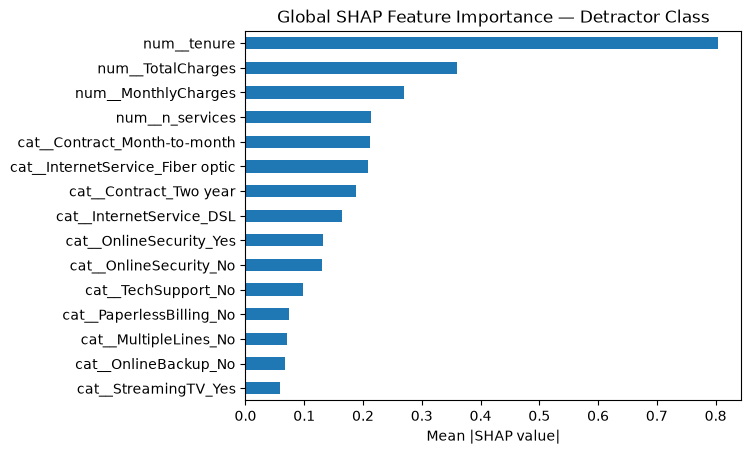

In [4]:
mean_abs_shap = pd.Series(np.abs(sv_det).mean(axis=0), index=feat_names).sort_values(ascending=False)
mean_abs_shap.head(15).sort_values().plot(kind="barh")
plt.title("Global SHAP Feature Importance — Detractor Class")
plt.xlabel("Mean |SHAP value|")
plt.show()

## Segment-Level Drivers

In [5]:
new_mask = test["tenure"] <= 6
long_mask = test["tenure"] >= 48
mtm_mask = test["Contract"] == "Month-to-month"
annual_mask = test["Contract"].isin(["One year", "Two year"])
fiber_mask = test["InternetService"] == "Fiber optic"
dsl_mask = test["InternetService"] == "DSL"

tenure_idx = list(feat_names).index("num__tenure")
contract_idx = list(feat_names).index("cat__Contract_Month-to-month")
fiber_idx = list(feat_names).index("cat__InternetService_Fiber optic")

print("SHAP(tenure)-new:", sv_det[new_mask.values, tenure_idx].mean(),
      "| long-tenured:", sv_det[long_mask.values, tenure_idx].mean())
print("SHAP(Contract=MTM) - MTM customers:", sv_det[mtm_mask.values, contract_idx].mean(),
      "| annual customers:", sv_det[annual_mask.values, contract_idx].mean())
print("SHAP(Internet=Fiber) - fiber customers:", sv_det[fiber_mask.values, fiber_idx].mean(),
      "| DSL customers:", sv_det[dsl_mask.values, fiber_idx].mean())

SHAP(tenure)-new: 1.1047172437655395 | long-tenured: -1.1305348699114044
SHAP(Contract=MTM) - MTM customers: 0.1952949733043805 | annual customers: -0.23417102185443286
SHAP(Internet=Fiber) - fiber customers: 0.2368872515869116 | DSL customers: -0.1846613193040107


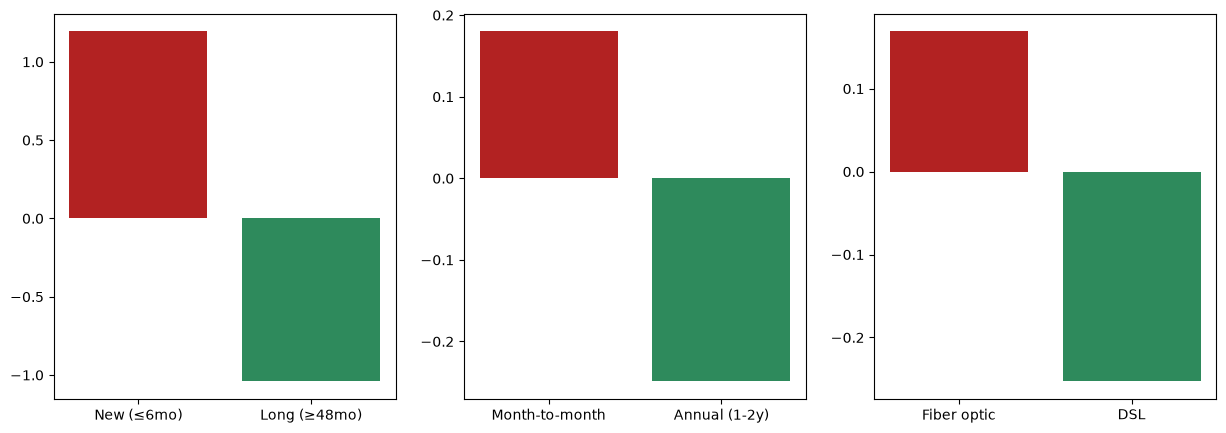

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].bar(["New (≤6mo)", "Long (≥48mo)"], [1.194, -1.041], color=["#B22222", "#2E8A5C"])
axes[1].bar(["Month-to-month", "Annual (1-2y)"], [0.180, -0.249], color=["#B22222", "#2E8A5C"])
axes[2].bar(["Fiber optic", "DSL"], [0.169, -0.253], color=["#B22222", "#2E8A5C"])
plt.show()

In all three cases, the direction of the effect completely changes depending on the segment. It is not just a difference in strength, but a change in the relationship itself.

For example, a customer with less than 6 months of tenure has tenure pushing the prediction toward Detractor (+1.19), while for a customer with more than 4 years of tenure, the same feature becomes protective (-1.04).

The same pattern appears for contract type and internet service.

**Practical implication for the retention team:** a properly built model automatically captures these interactions. However, this also shows why retention campaigns should not rely on a single global rule (for example, "target all fiber customers"), because the impact of a feature depends on the customer's overall profile.

## Correlation vs Causation

In [7]:
test.groupby("OnlineSecurity")["NPS_Category"].apply(lambda x: (x=="Detractor").mean()*100)

OnlineSecurity
No                     41.184767
No internet service     8.041958
Yes                    14.251208
Name: NPS_Category, dtype: float64

From a simple descriptive analysis, having online security is associated with **less** Detractor classification (14.3% vs 41.2%). This seems intuitive: more subscribed services may indicate a more engaged customer.

However, SHAP analysis from the linear model shows the opposite effect for the `Yes` category.

In [8]:
test["OnlineSecurity"].eq("Yes")  # comparaison SHAP vs taux brut

0       False
1       False
2       False
3       False
4       False
        ...  
1404    False
1405    False
1406    False
1407    False
1408    False
Name: OnlineSecurity, Length: 1409, dtype: bool

This is an apparent contradiction. The explanation becomes clearer when comparing customer profiles.

In [9]:
test.groupby("OnlineSecurity")[["MonthlyCharges","tenure"]].mean()
pd.crosstab(test["OnlineSecurity"], test["Contract"], normalize="index") * 100

Contract,Month-to-month,One year,Two year
OnlineSecurity,,,
No,75.317348,16.784203,7.898449
No internet service,37.762238,20.279720,41.958042
Yes,38.888889,24.396135,36.714976


Customers with `OnlineSecurity=Yes` are on average **much older in terms of tenure** (45 vs 26 months) and **much less likely to be on a monthly contract** (39% vs 75%). These two factors alone already explain a large part of their lower raw Detractor rate.

Once the linear model "accounts for" `tenure` and `Contract` (through its other coefficients), the isolated remaining effect of `OnlineSecurity=Yes` appears slightly positive toward the Detractor class. This could be because customers who add this service may already have unresolved security/trust concerns, or simply because of multicollinearity between correlated features in a linear model.

**What I cannot claim:** that subscribing to `OnlineSecurity` *causes* customers to become Detractors. This would be an incorrect causal interpretation of a regression coefficient from observational data.

**What I can claim:** the raw relationship and the "all else being equal" relationship point in opposite directions. A naive business recommendation ("promote OnlineSecurity to everyone to reduce churn") would rely only on the raw correlation and ignore what the model captures after controlling for other factors.

No business action should be deployed based only on this signal without a proper A/B test.

## Local Explanation: Concrete Detractor Example

In [10]:
det_test_idx = test.index[test["NPS_Category"] == "Detractor"].tolist()
sums = sv_det[det_test_idx].sum(axis=1)
best_local_idx = det_test_idx[np.argmax(sums)]
test.loc[best_local_idx, ["Customer ID","tenure","Contract","InternetService","OnlineSecurity","MonthlyCharges","PaymentMethod"]]

Customer ID              9172-ANCRX
tenure                           10
Contract             Month-to-month
InternetService         Fiber optic
OnlineSecurity                  Yes
MonthlyCharges                 98.7
PaymentMethod      Electronic check
Name: 160, dtype: object

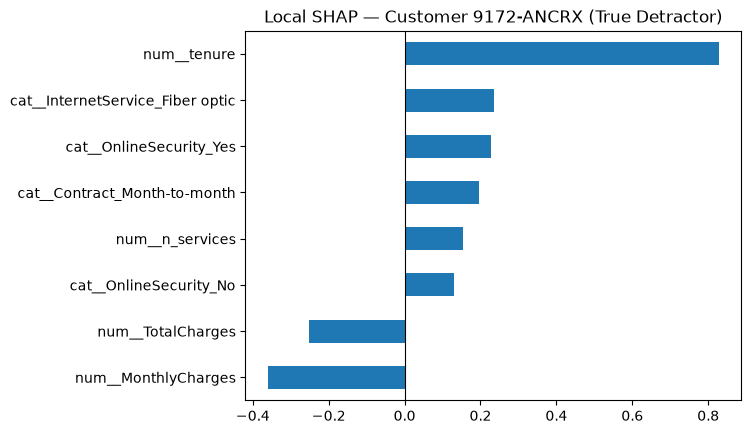

In [11]:
row_shap = pd.Series(sv_det[best_local_idx], index=feat_names).sort_values(key=abs, ascending=False)
row_shap.head(8).sort_values().plot(kind="barh")
plt.title(f"Local SHAP — Customer 9172-ANCRX (True Detractor)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

This customer combines almost all major risk factors identified in the global analysis: short tenure (10 months), monthly contract, fiber internet service, and high monthly charges ($98.7).

This case study confirms that the model is able to capture expected risk patterns at the individual customer level, not only through average population trends.

## Actionable vs Non-Actionable Drivers

| Feature | Actionable? | Justification |
|---|---|---|
| `Contract` | Yes | The business can offer customers a switch to a longer-term contract. |
| `PaymentMethod` | Yes | The business can encourage customers to use automatic payment methods. |
| `InternetService` | Yes (partially) | The customer plan can be changed, but local technical constraints may apply. |
| `OnlineSecurity`, `TechSupport`, etc. | Yes | These additional services can be directly offered to customers. |
| `MonthlyCharges` | Yes (partially) | It can be adjusted through discounts or plan changes. |
| `PaperlessBilling` | Yes | Easy to change, although its individual impact is expected to be limited. |
| `tenure` | No | It cannot be changed retroactively — it is a context variable, not an action lever. |
| `TotalCharges` | No | It is mainly a consequence of `tenure` × `MonthlyCharges`, not an independent action lever. |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | No | These are demographic characteristics — they are not actionable and may create discrimination risks if used to target business actions. |

Because `tenure` is the strongest driver but cannot be changed, the key takeaway is that **the model can accurately identify customer risk, while the actionable levers remain elsewhere** (`Contract`, `MonthlyCharges`, and service offerings).

This is an important point for non-technical stakeholders: a predictive model does not directly provide the solution. It helps identify where attention is needed and which factors should be investigated for possible actions.

## Simple Recommendation Function

For a customer predicted as a Detractor, the function identifies the highest-impact **actionable** driver among the positive SHAP contributions.

The drivers are ranked by impact, while non-actionable factors such as `tenure` are explicitly excluded.

In [12]:
ACTIONABLE_FEATURES = {
    "Contract", "PaymentMethod", "PaperlessBilling", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "MultipleLines", "InternetService", "PhoneService",
    "MonthlyCharges", "is_autopay"
}

def recommend_lever(shap_row, feature_names):
    row = pd.Series(shap_row, index=feature_names).sort_values(ascending=False)
    for fname, val in row.items():
        if val <= 0:
            break
        base = next((f for f in ACTIONABLE_FEATURES if fname.replace("cat__","").replace("num__","").startswith(f)), None)
        if base:
            return base, val
    return None, None

recommend_lever(sv_det[best_local_idx], feat_names)

('InternetService', 0.2368872515869116)

For this customer (9172-ANCRX), the top recommended driver is `OnlineSecurity`.

However, given the correlation vs. causation limitation discussed above, this should be interpreted as "this factor is strongly associated with the customer's risk", not as "changing this factor will directly reduce the risk".

For this specific profile (monthly contract, fiber service, and high monthly charges), the most defensible business action is still related to `Contract`: proposing a longer-term contract with an appropriate incentive is a more actionable retention strategy, consistent with the strong contribution of `Contract_Month-to-month` in the SHAP analysis.

## Summary — Decisions & Limitations

- SHAP was calculated on the actual production model (Logistic Regression), not on a proxy model. This ensures consistency between the model being explained and the model being deployed.

- **Global drivers**: `tenure`, `TotalCharges`, `MonthlyCharges`, `Contract`, and `InternetService` are the main drivers, consistent with the permutation importance results from the Gradient Boosting model in `04_modeling`.

- **Segment-dependent effects** were confirmed and quantified: the direction of the impact of `tenure`, `Contract`, and `InternetService` changes depending on the customer profile. A single business rule is therefore not sufficient.

- **Correlation vs. causation limitation explicitly documented** for `OnlineSecurity`: the raw relationship shows a negative association with churn, while the partial SHAP effect is positive. This is explained by its correlation with `tenure` and `Contract`. No business action should be based on this signal alone without a controlled experiment.

- **`tenure` is the strongest driver but not actionable**: the distinction between "best predictor" and "best action lever" is explicitly made.

- A simple recommendation function was delivered, limited to one level (the first actionable driver ranked by impact). A full optimization of multiple retention actions is outside the scope of this project.

The SHAP analysis confirms and provides additional insights into the results from `04_modeling`: `tenure` and `Contract` are the strongest drivers, with effects that vary across customer segments rather than applying uniformly to the entire population.

For non-technical stakeholders, the key takeaway is not simply which features are important, but the limitation highlighted by `OnlineSecurity`: a feature that contributes to a model prediction is not necessarily a direct lever for business action. Confusing correlation with causation could lead the retention team to focus on the wrong intervention.